In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. tensorflow v2.xx 에서 v1 사용하기

In [2]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior() # v2를 비활성화하고 v1 활성화
import numpy as np
import pandas as pd

Instructions for updating:
non-resource variables are not supported in the long term


## Tensorflow
- 데이터 흐름 그래프(tensor 객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session()으로 실행
- sess.run()을 통해 값을 확인

In [7]:
# tensor = data(상수, 변수)와 연산
node1 = tf.constant('Hello Tensorflow')
sess = tf.Session() # tensorflow 전원장치 Session()
print(sess.run(node1).decode())

Hello Tensorflow


In [11]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype = tf.float16)
node2 = tf.constant(20, dtype = tf.float16)
node3 = tf.add(node1, node2)
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [12]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype = tf.float32)
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [15]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1,2,3.,])
tensor = tf.reduce_mean(data) # sess.run 하면 평균값을 계산할 예정이다
sess = tf.Session()
sess.run(tensor)

2.0

In [3]:
# random값을 갖는 tensor => 스케일 조정을 평균이 0, 표준편차가 1인 정규분포를 주로 이용
tensor = tf.random_normal([2]) # 평균이 0, 표준편차가 1인, 난수 실수 2개(정규분포를 이루는 난수)
a = tf.random_normal([1]) # 평균이 0, 표준편차가 1인, 난수 실수 1개(정규분포를 이루는 난수)
b = tf.random_normal([1]) # 평균이 0, 표준편차가 1인, 난수 실수 1개(정규분포를 이루는 난수)
sess = tf.Session()
sess.run([a,b])
# sess.run(tensor)

[array([1.2476201], dtype=float32), array([-0.7669894], dtype=float32)]

In [10]:
w = tf.Variable(tf.random_normal([1])) # 학습에 따라 변화하는, 변수로 가중치 설정
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w 변수의 난수 초기화
sess.run(w)

array([-0.17854519], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
## 2.1 독립(입력)변수 x가 1개, 종속(타겟)변수 y가 1개

In [25]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight와 bias(처음에는 랜덤값으로 셋팅, 학습과정에서 변경)
w = tf.Variable(tf.random_normal([1]), name = 'weight')
b = tf.Variable(tf.random_normal([1]), name = 'bias')
# Hypothesis : 예측값(가설)
H = w*x + b
# cost function(손실함수 : loss, mse; 최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습 목적 : cost가 최소가 되는 w, b를 찾아내는 것
cost는 2차 함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강;Gradient descent Optimizer)
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.01) # 미분값
train = optimizer.minimize(cost)
# Session생성
sess = tf.Session()
# w,b 변수 노드의 초기화
sess.run(tf.global_variables_initializer())
# 학습 5000번(v2에서 fit함수)
for step in range(1,5001):
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b])
    if step%200 == 0 :
        print(f'{step}번째 cost : {cost_val}, w : {w_val}, b : {b_val}')

200번째 cost : 0.09765975922346115, w : [1.3620832], b : [0.17689961]
400번째 cost : 0.03729124739766121, w : [1.2237452], b : [0.49137402]
600번째 cost : 0.014239584095776081, w : [1.1382608], b : [0.6857004]
800번째 cost : 0.005437355488538742, w : [1.0854367], b : [0.80578226]
1000번째 cost : 0.0020762572530657053, w : [1.0527948], b : [0.879985]
1200번째 cost : 0.0007928204140625894, w : [1.0326241], b : [0.9258378]
1400번째 cost : 0.0003027391794603318, w : [1.0201597], b : [0.9541722]
1600번째 cost : 0.0001155944264610298, w : [1.0124573], b : [0.9716819]
1800번째 cost : 4.414047361933626e-05, w : [1.0076978], b : [0.982501]
2000번째 cost : 1.6855787180247717e-05, w : [1.0047569], b : [0.9891864]
2200번째 cost : 6.4364085119450465e-06, w : [1.0029395], b : [0.9933179]
2400번째 cost : 2.4582607238698984e-06, w : [1.0018166], b : [0.9958704]
2600번째 cost : 9.39135134103708e-07, w : [1.001123], b : [0.9974475]
2800번째 cost : 3.591905226585368e-07, w : [1.0006946], b : [0.99842167]
3000번째 cost : 1.37510767217

In [26]:
# 최종적으로 나온 회귀식 : H = w*x + b
sess.run([w,b])

[array([1.0000087], dtype=float32), array([0.9999811], dtype=float32)]

In [28]:
w_, b_ = sess.run([w,b])
w_[0], b_[0]


(1.0000087, 0.9999811)

In [29]:
def predict(int_x) :
    return w_[0]*int_x + b_[0]

In [32]:
input_x = int(input('입력값은? : '))
print('예측값은 : ',predict(input_x))

입력값은? : 5
예측값은 :  6.000024616718292


## 2.2 predict를 위한 placeholder 이용
- placeholder : 텐서플로우 외부에서 데이터를 입력 받는 노드

In [35]:
# x = np.array([1,2,3])
x = tf.placeholder(dtype=tf.float16) # 데이터는 전원(Session() 객체가 호출된 후에) 기입
H = 1*x + 1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [37]:
# data placeholder 설정
# H = 2x + 1
x_data = [1,2,3,5,8]
y_data = [3,5,7,11,17]
x = tf.placeholder(tf.float32) 
y = tf.placeholder(tf.float32) 
# 가중치 설정
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# 가설 설정
H = w*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.01)
train = optimizer.minimize(cost)
# 학습
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w, b 초기화
for step in range(5001) :
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b] , feed_dict={x : x_data, y : y_data})
    if step%200 == 0 :
        print(f'{step}번째 : cost : {cost_val}, w : {w_val}, b : {b_val}')

0째 : cost : 319.72735595703125, w : [-0.13076258], b : [0.3042154]
200째 : cost : 0.0024535830598324537, w : [2.0168452], b : [0.90996253]
400째 : cost : 0.0002413292386336252, w : [2.0052829], b : [0.9717623]
600째 : cost : 2.373584356973879e-05, w : [2.0016568], b : [0.9911442]
800째 : cost : 2.3347840851783985e-06, w : [2.0005195], b : [0.9972224]
1000째 : cost : 2.2970807833644358e-07, w : [2.000163], b : [0.99912846]
1200째 : cost : 2.2677294708728368e-08, w : [2.0000513], b : [0.9997264]
1400째 : cost : 2.238584873026639e-09, w : [2.000016], b : [0.99991417]
1600째 : cost : 2.3214852262753993e-10, w : [2.0000052], b : [0.9999722]
1800째 : cost : 3.616378377313545e-11, w : [2.0000021], b : [0.99998957]
2000째 : cost : 2.060005464821213e-11, w : [2.0000017], b : [0.99999213]
2200째 : cost : 2.060005464821213e-11, w : [2.0000017], b : [0.99999213]
2400째 : cost : 2.060005464821213e-11, w : [2.0000017], b : [0.99999213]
2600째 : cost : 2.060005464821213e-11, w : [2.0000017], b : [0.99999213]
2800

In [38]:
# 예측하기 predict
sess.run(H, feed_dict={x:5})

array([11.000001], dtype=float32)

In [39]:
sess.run(H, feed_dict={x : np.array([5,6,7])})

array([11.000001, 13.000002, 15.000004], dtype=float32)

## 2.3 scale이 다른 데이터의 linear regression 구현(scale 조정x)

In [43]:
# data placeholder 설정
x_data = [1,2,5,8,10]
y_data = [3,15,68,80,95]
x = tf.placeholder(tf.float32) 
y = tf.placeholder(tf.float32) 
# 가중치 설정
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# 가설 설정
H = w*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.01)
train = optimizer.minimize(cost)
# 학습
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w, b 초기화
for step in range(5001) :
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b] , feed_dict={x : x_data, y : y_data})
    if step%200 == 0 :
        print(f'{step}번째 : cost : {cost_val}, w : {w_val}, b : {b_val}') # 코스트가 쉽게 줄어들지 않음

0번째 : cost : 4615.2001953125, w : [7.6365843], b : [1.570997]
200번째 : cost : 83.77886962890625, w : [10.169933], b : [-0.3909534]
400번째 : cost : 83.50951385498047, w : [10.262501], b : [-1.0763469]
600번째 : cost : 83.48478698730469, w : [10.290539], b : [-1.2839469]
800번째 : cost : 83.4825439453125, w : [10.299031], b : [-1.3468274]
1000번째 : cost : 83.48235321044922, w : [10.301603], b : [-1.3658739]
1200번째 : cost : 83.48231506347656, w : [10.302382], b : [-1.3716427]
1400번째 : cost : 83.4823226928711, w : [10.302618], b : [-1.3733904]
1600번째 : cost : 83.48230743408203, w : [10.30269], b : [-1.3739195]
1800번째 : cost : 83.48230743408203, w : [10.3027115], b : [-1.3740784]
2000번째 : cost : 83.48233795166016, w : [10.302717], b : [-1.3741251]
2200번째 : cost : 83.48233032226562, w : [10.302718], b : [-1.3741326]
2400번째 : cost : 83.48233032226562, w : [10.302718], b : [-1.3741326]
2600번째 : cost : 83.48233032226562, w : [10.302718], b : [-1.3741326]
2800번째 : cost : 83.48233032226562, w : [10.3027

In [ ]:
# cost값이 멈춤 : Local 최소값 (Local Minima)에 빠졌을 때를 대비할 수 있음. 

## 2.4 scale이 다른 데이터의 Linear Regression을 구현(scale 조정O)
### scale을 맞추기 : 모든 데이터를 일정 범위 내로 조정
- normalization(정규화) : 데이터를 0 ~ 1 로 조정
                      X - Xmin
    normalization = ---------------------------------------------
                      Xmax - Xmin
                  * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler 이용)
                  
- standardization(표준화) : 평균 0, 표준편차 1로 조정
                        X - Xmean(평균)
    standardization = ------------------------------------------------ 
                        Xstd(표준편차)
                  * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler 이용)

In [50]:
# 1. 라이브러리 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min())/(x_data.max()-x_data.min())
scaled_y_data = (y_data - y_data.min())/(y_data.max()-y_data.min())
scaled_x_data, scaled_y_data

(array([0.        , 0.11111111, 0.44444444, 0.77777778, 1.        ]),
 array([0.        , 0.13043478, 0.70652174, 0.83695652, 1.        ]))

In [59]:
# 2. 라이브러리 쓰고 정규화 (MinMaxScaler 이용)
from sklearn.preprocessing import MinMaxScaler
x_data = np.array([1,2,5,8,10]).reshape(-1,1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
# np.column_stack([x_data,y_data])
scaler_x = MinMaxScaler() # x데이터를 정규화 시킬 객체(2차원만 가능)
scaler_y = MinMaxScaler() # y데이터를 정규화 시킬 객체
# scaler_x.fit(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data,y_data,scaled_x_data,scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [65]:
x = tf.placeholder(tf.float32) 
y = tf.placeholder(tf.float32) 
# 가중치 설정
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# 가설 설정
H = w*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.001)
train = optimizer.minimize(cost)
# 학습
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w, b 초기화
for step in range(120000) :
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b] , feed_dict={x : scaled_x_data, y : scaled_y_data})
    if step%500 == 0 :
        print(f'{step}번째 : cost : {cost_val}, w : {w_val}, b : {b_val}') # 코스트가 쉽게 줄어들지 않음

0번째 : cost : 0.27128010988235474, w : [0.2611814], b : [0.8368263]
500번째 : cost : 0.1176227480173111, w : [0.2491629], b : [0.57369137]
1000번째 : cost : 0.0870419591665268, w : [0.30557093], b : [0.46653792]
1500번째 : cost : 0.07032749801874161, w : [0.3750397], b : [0.40763822]
2000번째 : cost : 0.05770568177103996, w : [0.4423998], b : [0.36568487]
2500번째 : cost : 0.047758057713508606, w : [0.5039403], b : [0.33134985]
3000번째 : cost : 0.039882026612758636, w : [0.5591696], b : [0.30165324]
3500번째 : cost : 0.03364323079586029, w : [0.60845643], b : [0.27546957]
4000번째 : cost : 0.02870108187198639, w : [0.65236104], b : [0.25223625]
4500번째 : cost : 0.024786027148365974, w : [0.69144917], b : [0.2315781]
5000번째 : cost : 0.021684642881155014, w : [0.726242], b : [0.21319738]
5500번째 : cost : 0.019227810204029083, w : [0.75721], b : [0.19683939]
6000번째 : cost : 0.017281580716371536, w : [0.784773], b : [0.18228064]
6500번째 : cost : 0.015739837661385536, w : [0.8093052], b : [0.16932304]
7000번째 

57000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
57500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
58000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
58500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
59000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
59500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
60000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
60500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
61000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
61500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
62000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
62500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
63000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
63500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0

114000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
114500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
115000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
115500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
116000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
116500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
117000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
117500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
118000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
118500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
119000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
119500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]


In [74]:
# 예측 : 모델에 scale 조정된 값으로 예측 => scale 조정된 y값 반환
scaled_input = scaler_x.transform(np.array([[2],
                                           [3]]))
print('모델 예측을 위한 입력 :',scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :',scaled_output, sep='\n')
print('결과 : ',scaler_y.inverse_transform(scaled_output),sep='\n')

모델 예측을 위한 입력 :
[[0.11111111]
 [0.22222222]]
모델 예측 결과 :
[[0.17650405]
 [0.2884667 ]]
결과 : 
[[19.238373]
 [29.538935]]


In [82]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat) # 기존 [3,15,68,80,95]
y_hat

array([[  8.937809],
       [ 19.238373],
       [ 50.140057],
       [ 81.04175 ],
       [101.64287 ]], dtype=float32)

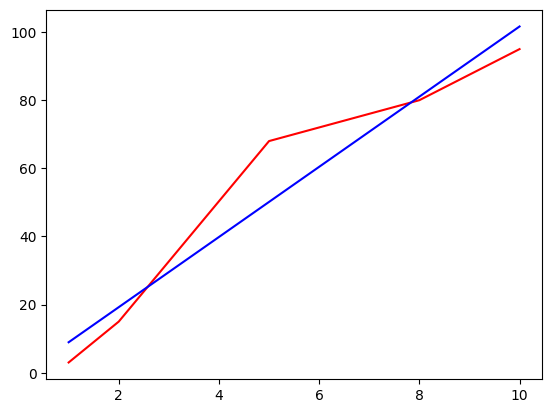

In [83]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

In [95]:
# 라이브러리를 사용하여 표준화(standardization) : StandardScaler
from sklearn.preprocessing import StandardScaler
x_data, y_data
x_scaler = StandardScaler() # x_data를 표준화할 객체
y_scaler = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = x_scaler.fit_transform(x_data)
scaled_y_data = y_scaler.fit_transform(y_data)
print(np.column_stack([x_data,y_data]))
print(np.column_stack([scaled_x_data,scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [99]:
x = tf.placeholder(tf.float32) 
y = tf.placeholder(tf.float32) 
# 가중치 설정
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# 가설 설정
H = w*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.001)
train = optimizer.minimize(cost)
# 학습
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w, b 초기화
for step in range(12000) :
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b] , feed_dict={x : scaled_x_data, y : scaled_y_data})
    if step%500 == 0 :
        print(f'{step}번째 : cost : {cost_val}, w : {w_val}, b : {b_val}') # 코스트가 쉽게 줄어들지 않음

0번째 : cost : 1.9001833200454712, w : [-0.38464457], b : [0.01010579]
500번째 : cost : 0.3108662962913513, w : [0.47098288], b : [0.00371399]
1000번째 : cost : 0.09620608389377594, w : [0.78543544], b : [0.00136494]
1500번째 : cost : 0.06721308827400208, w : [0.9010004], b : [0.00050164]
2000번째 : cost : 0.06329718232154846, w : [0.94347197], b : [0.00018437]
2500번째 : cost : 0.06276829540729523, w : [0.95908034], b : [6.7763984e-05]
3000번째 : cost : 0.06269683688879013, w : [0.9648168], b : [2.4912888e-05]
3500번째 : cost : 0.06268720328807831, w : [0.966925], b : [9.163889e-06]
4000번째 : cost : 0.06268589943647385, w : [0.96769965], b : [3.3760318e-06]
4500번째 : cost : 0.06268572062253952, w : [0.9679846], b : [1.2490098e-06]
5000번째 : cost : 0.06268570572137833, w : [0.9680879], b : [4.6787508e-07]
5500번째 : cost : 0.06268569082021713, w : [0.9681264], b : [1.7818148e-07]
6000번째 : cost : 0.06268569082021713, w : [0.96813506], b : [7.975901e-08]
6500번째 : cost : 0.06268568336963654, w : [0.96813506],

In [102]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = y_scaler.inverse_transform(scaled_y_hat) # 기존 [3,15,68,80,95]
y_hat

array([[  8.929233],
       [ 19.2318  ],
       [ 50.13949 ],
       [ 81.04718 ],
       [101.6523  ]], dtype=float32)

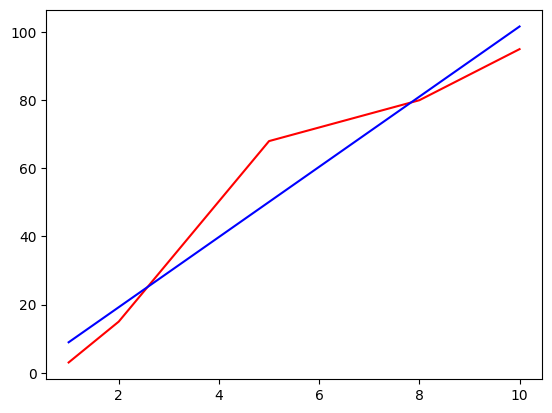

In [103]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')